In [278]:
## Imports and Initialization -------------------------------------------------|
print("Importing dependencies... ")

import random, math
import sys, time
import os, os.path
sys.path.insert(0, "..")

# third party
import numpy as np
from astropy.io import fits
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter

# internal
import abstraction
import algorithm
from astropy.io import fits
from utility import IndexSchema, get_fits_paths, load_image_data
from examples.fits_to_mp4 import fits_to_mp4, data_to_mp4
from reference_method import ExternalRefs, RollingWindow

## Fetch Data ------------------------------------------------------------------

frame_num = 3

files_dir = os.path.abspath(os.path.join(".", "media"))
files = get_fits_paths(files_dir)
files = files[frame_num:frame_num + 2]
# print("\n".join(files))
print(f"{len(files)} files found")

# create variable paths for destretching files
kernel_sizes: np.ndarray[np.int64] = np.array([16])
out_off_dir = os.path.join(files_dir, "off")
out_off_dir_ccfilt = os.path.join(out_off_dir, "ccfilt")

Importing dependencies... 
2 files found


# Calculate offsets between two images

In [279]:
start = time.time()

# calculate offset vectors
algorithm.USE_CC_FILTERING = False
abstraction.calc_offset_vectors(
	files,
	out_off_dir,
	"off",
	kernel_sizes=kernel_sizes,
)

correlations = algorithm.SUBFIELD_CORRS

algorithm.USE_CC_FILTERING = True
abstraction.calc_offset_vectors(
	files,
	out_off_dir_ccfilt,
	"off",
	kernel_sizes=kernel_sizes,
)

elapsed = time.time() - start
print(f"elapsed time: {elapsed}")

Searching for image data in specified files...
processing image #0../home/tteck/Documents/Development/flct_destretch/flctdestretch/examples/media/test_1k_02.fits
processing image #1../home/tteck/Documents/Development/flct_destretch/flctdestretch/examples/media/test_1k_03.fits
Searching for image data in specified files...
processing image #0../home/tteck/Documents/Development/flct_destretch/flctdestretch/examples/media/test_1k_02.fits
processing image #1../home/tteck/Documents/Development/flct_destretch/flctdestretch/examples/media/test_1k_03.fits
elapsed time: 27.650330781936646


# Visualize artifacts by plotting log-scale values (very dark and light spots are artifacts)

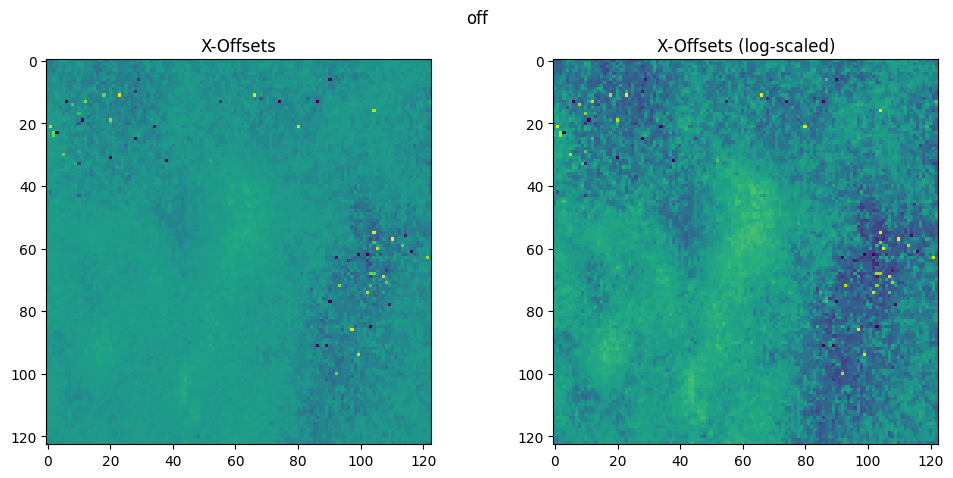

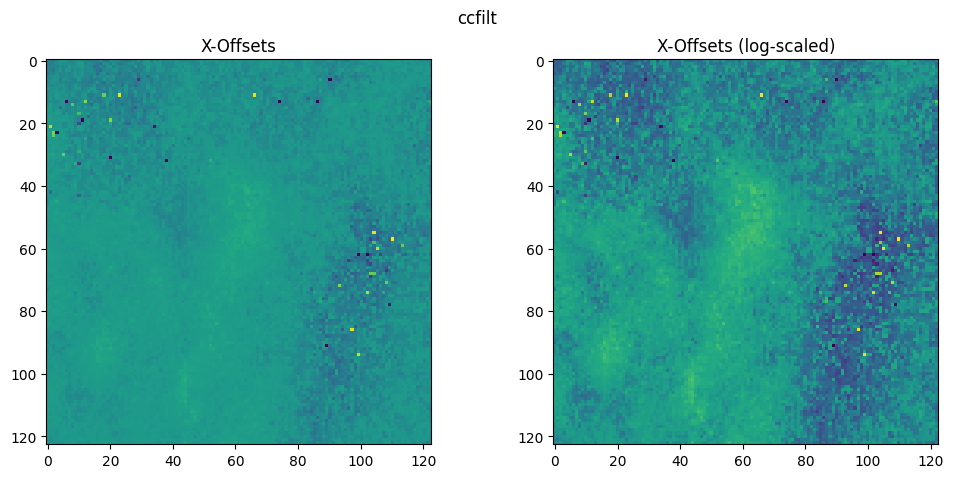

In [280]:
axis_index = 1
dirs = [out_off_dir, out_off_dir_ccfilt]

off_data: np.ndarray = None
off_outliers: list[tuple[tuple[int, int], float]] = []
off_control: list[tuple[tuple[int, int], float]] = []
off_offset: float = 0

# visualize both the original offsets, and the offsets after the cross
# correlation filter is applied
for i, dir in enumerate(dirs):
	# load offset data
	files = get_fits_paths(dir)
	data = load_image_data(files[-1], None, None)

	# log-scale the offsets so smaller structures are visible
	data_logscl = data.copy()
	data_logscl -= np.median(data_logscl)
	data_logscl = np.sign(data_logscl) * np.log1p(np.abs(data_logscl))
	
	# normalize logscaled offs
	min_logscl = data_logscl.min()
	range_logscl = max(0.1, data_logscl.max() - min_logscl)
	data_logscl = (data_logscl - min_logscl) / range_logscl
	
	# normalize offs
	data_min = data.min()
	data_max = data.max()
	data_range = max(data_max - data_min, 0.1)
	data = (data - data_min) / data_range

	# save some data about offsets outside the loop
	if i == 0:
		off_offset = data_min / data_range
		off_data = data[axis_index]
		off_lower = np.percentile(off_data, 0.25)
		off_upper = np.percentile(off_data, 99.75)
		off_iqr = off_upper - off_lower
		shift_thresh = 0 # off_iqr * 2 #+ 0.5 * kernel_sizes[-1] / data_range
		outlier_mask = (off_data < off_lower - shift_thresh) | (off_data > off_upper + shift_thresh)
		outlier_indices = list(map(tuple, np.column_stack(np.where(outlier_mask))))
		off_outliers = [
			(i, off_data[i])
			for i in outlier_indices
		]
		control_mask = (
			(off_data > np.percentile(off_data, 25)) &
			(off_data < np.percentile(off_data, 75))
		)
		control_indices = list(map(tuple, np.column_stack(np.where(control_mask))))
		control_indices_flat = [
			random.choice(control_indices)
			for x in range(0, len(off_outliers))
		]
		off_control = [
			(i, off_data[i])
			for i in control_indices_flat
		]

	# plot the images
	plt.figure(figsize=(12,5))
	
	plt.subplot(1,2,1)
	plt.imshow(data[axis_index, :, :], vmin=0, vmax=1)
	plt.title(f"{"YX"[axis_index]}-Offsets")
	
	plt.subplot(1,2,2)
	plt.imshow(data_logscl[axis_index, :, :], vmin=0, vmax=1)
	plt.title(f"{"YX"[axis_index]}-Offsets (log-scaled)")
	
	plt.suptitle(dir.split('/')[-1])
	plt.show()


# Inspect cross correlations for artifacts

184386.18181170116
1119533.65637302


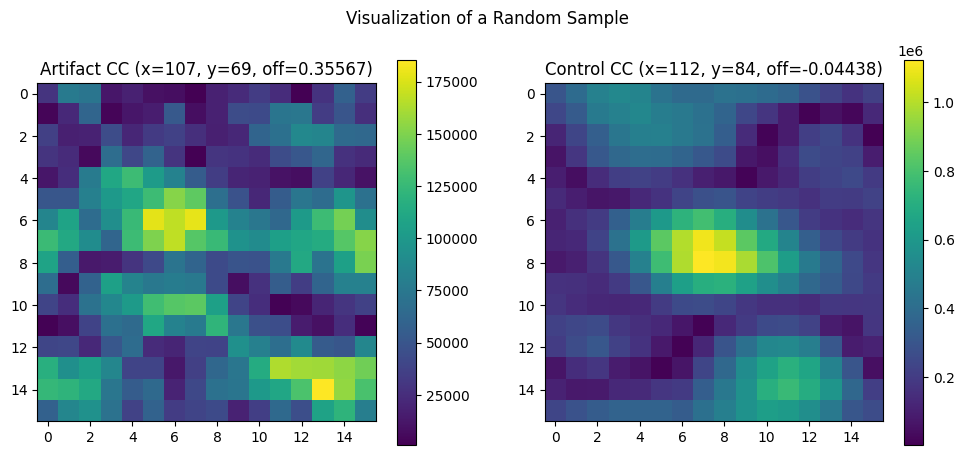

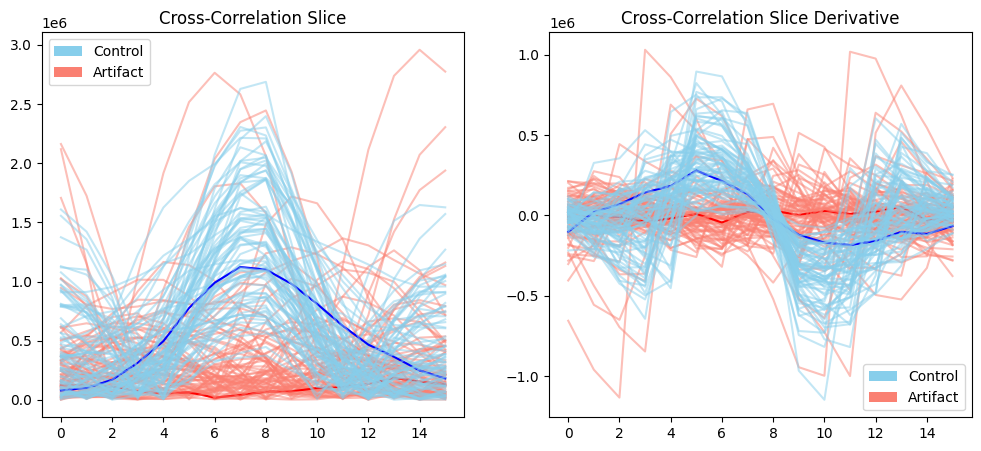

In [281]:
cc_size = kernel_sizes[-1]

# global variables for control and artifact
artifact = None
control = None
cca_index_x = None
cca_index_y = None
artifact_cross_correlation = None
cca_corr = None
cca_corr_min = None
ccc_index_x = None
ccc_index_y = None
control_cross_correlation = None
ccc_corr = None
ccc_corr_min = None

def pick_random_ac():
	global artifact, control, cca_index_x, cca_index_y, artifact_cross_correlation
	global cca_corr, cca_corr_min, ccc_index_x, ccc_index_y, control_cross_correlation
	global ccc_corr, ccc_corr_min

	# pick random artifact from outliers
	artifact = random.choice(off_outliers)[0]

	# control point (no artifact)
	control = random.choice(off_control)[0]

	# artifact cross correlation data
	cca_index_x = cc_size * artifact[0]
	cca_index_y = cc_size * artifact[1]
	artifact_cross_correlation = correlations[
	    axis_index,  
	    cca_index_x : cca_index_x + cc_size,
	    cca_index_y : cca_index_y + cc_size, 
	]
	cca_corr = artifact_cross_correlation.max()
	cca_corr_min = artifact_cross_correlation.min()

	# control cross correlation data
	ccc_index_x = cc_size * control[0]
	ccc_index_y = cc_size * control[1]
	control_cross_correlation = correlations[
	    axis_index,
	    ccc_index_x : ccc_index_x + cc_size,
	    ccc_index_y : ccc_index_y + cc_size,
	]
	ccc_corr = control_cross_correlation.max()
	ccc_corr_min = control_cross_correlation.min()

pick_random_ac()
print(cca_corr - cca_corr_min)
print(ccc_corr - ccc_corr_min)

# plot the cross correlations
rounding_amount = 1e5
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(artifact_cross_correlation)
plt.title(f"Artifact CC (x={artifact[1]}, y={artifact[0]}, off={
	round((off_data[artifact] + off_offset) * rounding_amount) / rounding_amount
})")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(control_cross_correlation)
plt.title(f"Control CC (x={control[1]}, y={control[0]}, off={round((off_data[control] + off_offset) * rounding_amount) / rounding_amount})")
plt.colorbar()

plt.suptitle("Visualization of a Random Sample")
plt.show()

# plot the vertical slices and derivatives to see their shapes better
plt.figure(figsize=(12,5))
color_control = "skyblue"
color_artifact = "salmon"

for arr in [off_outliers, off_control]:
	base_col = color_artifact if arr == off_outliers else color_control
	highlight_col = "red" if arr == off_outliers else "blue"
	for xy, shift in arr:
		cca_max_x = xy[0] * cc_size
		cca_max_y = xy[1] * cc_size
		cc_window = (correlations[
			axis_index,
			cca_max_x : cca_max_x + cc_size,
			cca_max_y : cca_max_y + cc_size,
		])
		cc_max_index = np.argmax(cc_window)
		cc_max_index_x = math.floor(cc_max_index / cc_size)
		cc_max_index_y = int(cc_max_index_x % cc_size)
		slice = cc_window[cc_max_index_x]

		alpha = 0.5
		color = base_col
		if (xy[0] == artifact[0] and xy[1] == artifact[1]) or (xy[0] == control[0] and xy[1] == control[1]): 
			alpha = 1
			color = highlight_col

		plt.subplot(1,2,1)
		plt.plot(slice, color=color, alpha=alpha)

		plt.subplot(1,2,2)
		slice = [
			x - slice[i-1]
			for i, x in enumerate(slice)
		]
		plt.plot(slice, color=color, alpha=alpha)

plt.subplot(1,2,1)
plt.title("Cross-Correlation Slice")
plt.legend(handles=[
	Patch(facecolor=color_control, label="Control"),
	Patch(facecolor=color_artifact, label="Artifact"),
])

plt.subplot(1,2,2)
plt.title("Cross-Correlation Slice Derivative")
plt.legend(handles=[
	Patch(facecolor=color_control, label="Control"),
	Patch(facecolor=color_artifact, label="Artifact"),
])

plt.show()

# There are some differences here between the artifact and control but not consistent enough to be useful

------------------------

# Now we will try comparing cross correlation radial averages

112 84 (np.int64(69), np.int64(107))
107 69 (np.int64(69), np.int64(107))


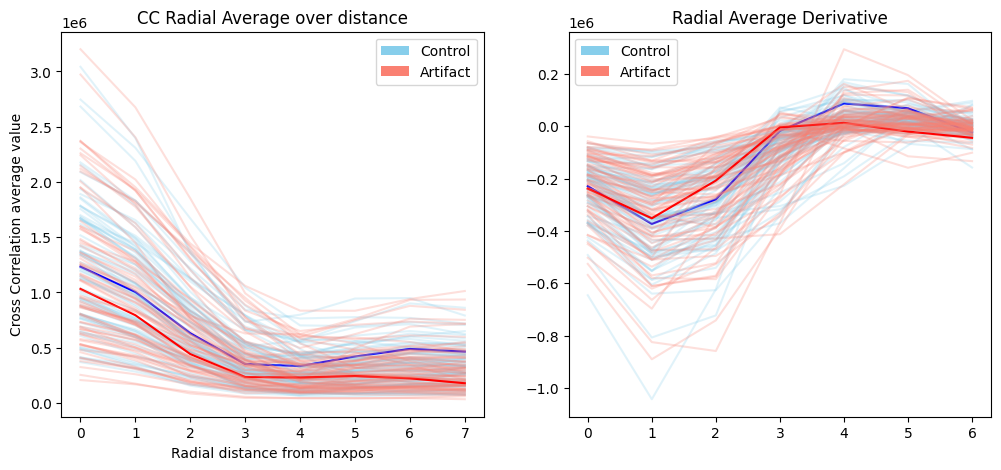

In [282]:
# Smooth transition band
def smoothstep(edge0: float, edge1: float, r: np.ndarray) -> np.ndarray:
	t = np.clip((r - edge0) / (edge1 - edge0), 0, 1)
	# cubic Hermite interpolation
	return t * t * (3 - 2 * t)  

def smooth_radial_average(
	arr: np.ndarray, 
	center: tuple[float, float], 
	r_min: float, 
	r_max:float,
	transition: float=0.5
) -> float:
	ny, nx = arr.shape
	y, x = np.ogrid[:ny, :nx]
	cy, cx = center
	r = np.sqrt((x - cx) ** 2 + (y - cy) ** 2)

	# create radial mask
	mask_inner = smoothstep(r_min - transition, r_min + transition, r)
	mask_outer = 1 - smoothstep(r_max - transition, r_max + transition, r)
	mask = mask_inner * mask_outer

	# if mask does not overlap array, return 0
	total_weight = np.sum(mask)
	if total_weight == 0:
		return 0.0
	
	# find the average of the masked array
	return np.sum(arr * mask) / total_weight

def plot_avgs(subwindow_positions: list[tuple[int, int]], color, alpha: float , highlight_col):
	for y, x in subwindow_positions:
		wx = x * cc_size
		wy = y * cc_size
		cc_window = (correlations[
			axis_index,
			wx : wx + cc_size,
			wy : wy + cc_size,
		])
		cc_max_index = np.argmax(cc_window)
		cc_max_index_x = math.floor(cc_max_index / cc_size)
		cc_max_index_y = int(cc_max_index % cc_size)

		radial_samples = 8
		avgs = np.zeros((radial_samples))
		for i in range(0, radial_samples):
			avg = smooth_radial_average(
				cc_window, 
				(cc_max_index_x, cc_max_index_y),
				i, i + 1
			)
			avgs[i] = avg
		plt.subplot(1,2,1)
		col = color
		alph = alpha
		if (x == artifact[1] and y == artifact[0]) or (x == control[1] and y == control[0]): 
			print(x, y, artifact)
			alph = 1
			col = highlight_col
		plt.plot(avgs, color=col, alpha=alph)

		plt.subplot(1,2,2)
		deriv = []
		for i in range(1, len(avgs)):
			deriv.append(avgs[i] - avgs[i-1])
		plt.plot(deriv, color=col, alpha=alph)

# plot the radial averages of the controls and the artifacts
control_windows = [ x[0] for x in off_control ]
artifact_windows = [ x[0] for x in off_outliers ]
plt.figure(figsize=(12,5))

plot_avgs(control_windows, color_control, 0.25, "blue")
plot_avgs(artifact_windows, color_artifact, 0.25, "red")

# format plot
plt.subplot(1,2,1)
plt.title("CC Radial Average over distance")
plt.xlabel("Radial distance from maxpos")
plt.ylabel("Cross Correlation average value")
plt.legend(handles=[
	Patch(facecolor=color_control, label="Control"),
	Patch(facecolor=color_artifact, label="Artifact"),
])

plt.subplot(1,2,2)
plt.title("Radial Average Derivative")
plt.legend(handles=[
	Patch(facecolor=color_control, label="Control"),
	Patch(facecolor=color_artifact, label="Artifact"),
])

# No noticeable differences ¯\\\_(ツ)_/¯

-------

# We'll try looking at differences between local maxima on the cross correlation

          Artifact          |      Control
Max:   1015460.7144452598   |     1102826.4568993722
2nd:    736321.1476931772   |     423616.07344130485
Dif:   279139.56675208255   |      679210.3834580673


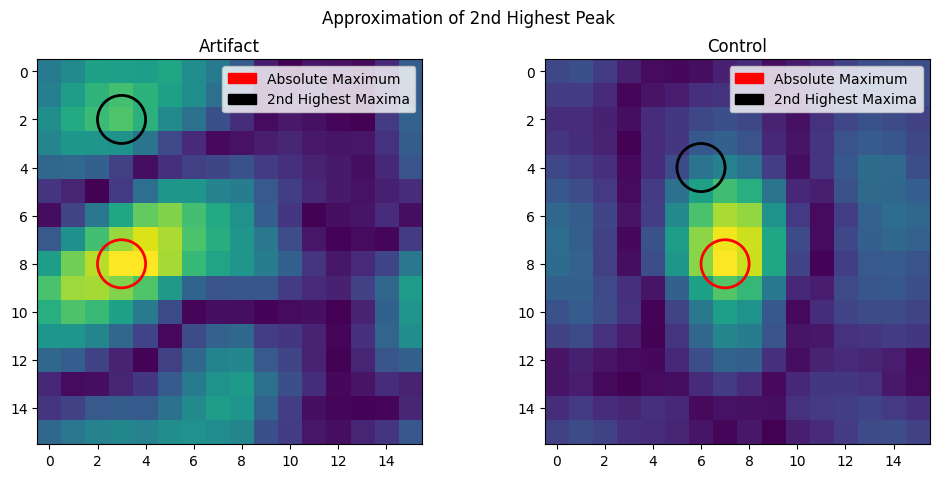

In [283]:
def get_peak_mask(
    center: tuple[int, int], 
    shape: tuple[int, int], 
    min_range: float
) -> np.ndarray:
    ix, iy = center
    wx, wy = np.indices(shape)
    coord_dist_sq = (wx - ix) ** 2 + (wy - iy) ** 2
    return coord_dist_sq > min_range * min_range

# neighbor order:
# top left,     top center,     top right, 
# mid left,                     mid right, 
# botton left,  bottom center,  bottom right
neighbs_x = np.array([-1, 0, 1, -1, 1, -1, 0 ,1])
neighbs_y = np.array([-1, -1, -1, 0, 0, 1, 1, 1])

# algorithm to find local maxima from a given starting point by 
# crawling upwards to higher values
def find_local_maxima(start_corrd: tuple[int, int], arr: np.ndarray) -> tuple[int, int]:
    do_loop = True
    ix, iy = start_corrd
    while do_loop:
        curr_val = arr[ix, iy]
        cneighbs_x = (neighbs_x + ix) % cc_size
        cneighbs_y = (neighbs_y + iy) % cc_size
        neighbs = arr[cneighbs_x, cneighbs_y]
        max_neighb = np.argmax(neighbs)
        max_neighb_val = neighbs[max_neighb]
        do_loop = max_neighb_val > curr_val
        if do_loop:
            ix = (ix + neighbs_x[max_neighb]) % cc_size
            iy = (iy + neighbs_y[max_neighb]) % cc_size
    return ix, iy

pick_random_ac()

# process artifact cross correlation
cca_max_x, cca_max_y = divmod(artifact_cross_correlation.argmax(), cc_size)
cca_mask = get_peak_mask(
    (cca_max_x, cca_max_y), 
    artifact_cross_correlation.shape, 
    cc_size * 0.25
)

cca_masked = artifact_cross_correlation.copy()
cca_masked[~cca_mask] = -np.inf
cca_max_x2, win_max_y2 = divmod(cca_masked.argmax(), cc_size)
cca_peak = find_local_maxima((cca_max_x2, win_max_y2), cca_masked)

# process control cross correlation
ccc_max_x, ccc_max_y = divmod(control_cross_correlation.argmax(), cc_size)
ccc_mask = get_peak_mask(
    (ccc_max_x, ccc_max_y), 
    control_cross_correlation.shape, 
    cc_size * 0.25
)

ccc_masked = control_cross_correlation.copy()
ccc_masked[~ccc_mask] = -np.inf
ccc_max_x2, ccc_max_y2 = divmod(ccc_masked.argmax(), cc_size)
ccc_peak = find_local_maxima((ccc_max_x2, ccc_max_y2), ccc_masked)

# display numerical comparisons
amax1 = artifact_cross_correlation[cca_max_x, cca_max_y]
amax2 = artifact_cross_correlation[cca_peak]
cmax1 = control_cross_correlation[ccc_max_x, ccc_max_y]
cmax2 = control_cross_correlation[ccc_peak]
print("          Artifact          |      Control")
print(f"Max: {str(amax1).rjust(20, ' ')}   |   {str(cmax1).rjust(20, ' ')}")
print(f"2nd: {str(amax2).rjust(20, ' ')}   |   {str(cmax2).rjust(20, ' ')}")
print(f"Dif: {str(amax1 - amax2).rjust(20, ' ')}   |   {str(cmax1 - cmax2).rjust(20, ' ')}")

# plot images and peaks
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(artifact_cross_correlation)
plt.gca().add_patch(plt.Circle((cca_peak[1], cca_peak[0]), 1, color="black", linewidth=2, fill=False))
plt.gca().add_patch(plt.Circle((cca_max_y, cca_max_x), 1, color="red", linewidth=2, fill=False))
plt.legend(handles=[
    Patch(color="red", label="Absolute Maximum"),
    Patch(color="black", label="2nd Highest Maxima"),
])
plt.title("Artifact")

plt.subplot(1,2,2)
plt.imshow(control_cross_correlation)
plt.gca().add_patch(plt.Circle((ccc_peak[1], ccc_peak[0]), 1, color="black", linewidth=2, fill=False))
plt.gca().add_patch(plt.Circle((ccc_max_y, ccc_max_x), 1, color="red", linewidth=2, fill=False))
plt.legend(handles=[
    Patch(color="red", label="Absolute Maximum"),
    Patch(color="black", label="2nd Highest Maxima"),
])
plt.title("Control")

plt.suptitle("Approximation of 2nd Highest Peak")
plt.show()

# Now lets try a statistical comparison

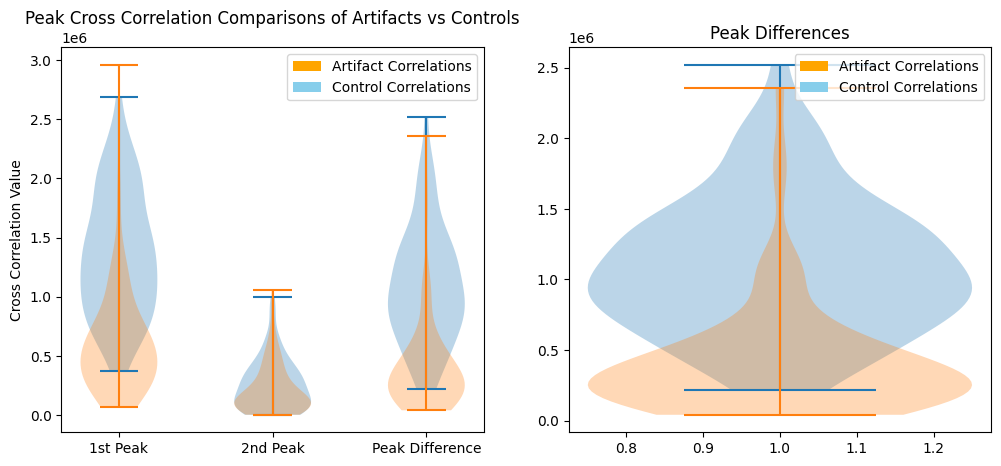

In [284]:
def get_peak_heights(windows_indices: list[tuple[tuple[int, int], float]]) -> np.ndarray:
	values = np.zeros((2, len(windows_indices)))
	for i, (window_i, shift) in enumerate(windows_indices):
		wx = window_i[0] * cc_size
		wy = window_i[1] * cc_size
		window = (correlations[
			axis_index,
			wx : wx + cc_size,
			wy : wy + cc_size,
		])
		max_x, max_y = divmod(window.argmax(), cc_size)
		win_mask = get_peak_mask(
			(max_x, max_y), 
			artifact_cross_correlation.shape, 
			cc_size * 0.25
		)

		win_masked = artifact_cross_correlation.copy()
		win_masked[~win_mask] = -np.inf
		win_max_x2, win_max_y2 = divmod(win_masked.argmax(), cc_size)
		win_peak = find_local_maxima((win_max_x2, win_max_y2), win_masked)
		values[0, i] = window[max_x, max_y]
		values[1, i] = window[win_peak]

	return values

# calculate difs
artifact_heights = get_peak_heights(off_outliers)
control_heights = get_peak_heights(off_control)
artifact_difs = artifact_heights[0,:] - artifact_heights[1,:]
control_difs = control_heights[0,:] - control_heights[1,:]


# plot the results
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.violinplot([
	(control_heights[0,:]),
	(control_heights[1,:]),
	(control_difs)
])
plt.violinplot([
	(artifact_heights[0,:]), 
	(artifact_heights[1,:]), 
	(artifact_difs)
])
plt.ylabel("Cross Correlation Value")
plt.xticks(ticks=[1,2,3], labels=["1st Peak", "2nd Peak", "Peak Difference"])
plt.legend(handles=[
	Patch(facecolor="orange", label="Artifact Correlations"),
	Patch(facecolor="skyblue", label="Control Correlations"),
])
plt.title("Peak Cross Correlation Comparisons of Artifacts vs Controls")

plt.subplot(1,2,2)
plt.violinplot(control_difs)
plt.violinplot(artifact_difs)
plt.legend(handles=[
	Patch(facecolor="orange", label="Artifact Correlations"),
	Patch(facecolor="skyblue", label="Control Correlations"),
])
plt.title("Peak Differences")

plt.show()

# The difference between peaks is clearly a useful filter

-----------

# Now, lets apply a filter based on this

In [298]:
cleaned_data = load_image_data(get_fits_paths(out_off_dir_ccfilt)[-1], None, None)
cleaned_data_2d = cleaned_data[axis_index]
datashape_x, datashape_y = cleaned_data_2d.shape
_, cc_windows_x, cc_windows_y = correlations.shape
cc_windows_x = round(cc_windows_x / cc_size)
cc_windows_y = round(cc_windows_y / cc_size)

# properties that change how the filter works
peak_thresh = np.percentile(control_difs, 10)
cc_filter_radius = 9

# mark invalid ccs as NaN
cc_filter_count = 0
for x in range(cc_windows_x):
    for y in range(cc_windows_y):
        peak1, peak2 = get_peak_heights([((x, y),0)])
        peak_dif = peak1 - peak2
        if peak_dif < peak_thresh:
            cc_filter_count += 1
            cleaned_data_2d[x, y] = np.nan

# define offsets to sample mean from
xneighbs = (np.floor(np.arange(cc_filter_radius ** 2 * 2) / cc_filter_radius) - cc_filter_radius).astype(np.int64)
yneighbs = (np.arange(cc_filter_radius ** 2 * 2) % (cc_filter_radius * 2) - cc_filter_radius).astype(np.int64)

# as long as there are nan values, iterate through them and take their neighbors mean
keptnan = True
didchange = True
while keptnan and didchange:
    keptnan = False
    didchange = False
    for x in range(cc_windows_x):
        for y in range(cc_windows_y):
            value = cleaned_data_2d[x, y]
            if np.isnan(value):
                cxneighbs = (xneighbs + x) % datashape_x
                cyneighbs = (yneighbs + y) % datashape_y
                mean_shift = np.nanmean(cleaned_data_2d[cxneighbs, cyneighbs])
                if(np.isnan(mean_shift)):
                    keptnan = True
                else:
                    didchange = True
                    cleaned_data_2d[x, y] = mean_shift

# if the array became stagnant and could not evaluate any neighboring means,
# replace nan markers with low values
if not didchange:
    for x in range(cc_windows_x):
        for y in range(cc_windows_y):
            value = cleaned_data_2d[x, y]
            if np.isnan(value):
                cleaned_data_2d[x, y] = -cc_size


print("filtered subwindows:", cc_filter_count, " out of ", cleaned_data_2d.size)

2461  out of  15129


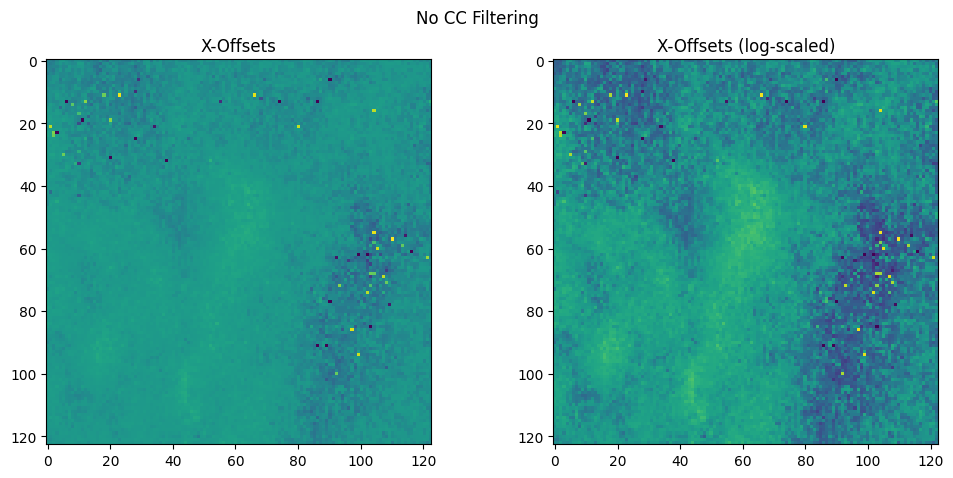

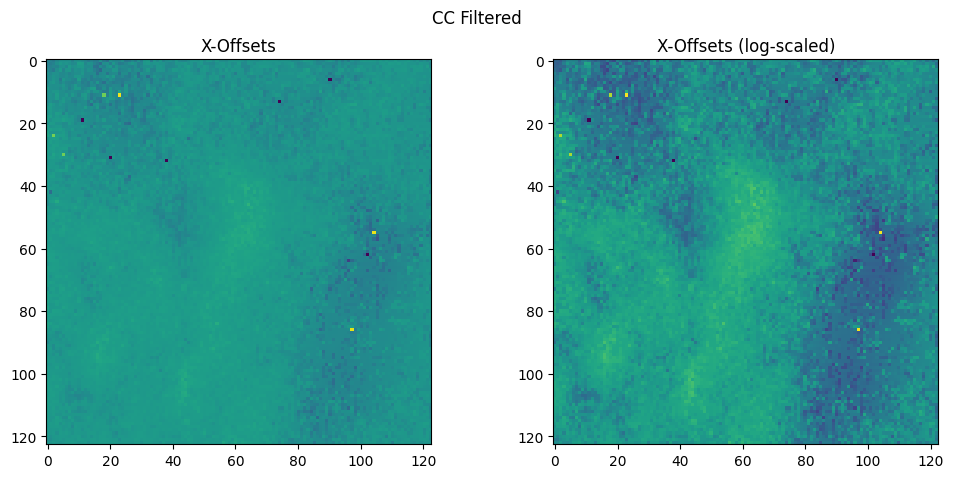

In [295]:

# visualize both the original offsets, and the offsets after the cross
# correlation filter is applied
for i, dir in enumerate([out_off_dir, None]):
	# load offset data
	files = None
	data = None
	if dir is not None:
		files = get_fits_paths(dir)
		data = load_image_data(files[-1], None, None)
	else:
		data = cleaned_data

	# log-scale the offsets so smaller structures are visible
	data_logscl = data.copy()
	data_logscl -= np.median(data_logscl)
	data_logscl = np.sign(data_logscl) * np.log1p(np.abs(data_logscl))
	
	# normalize logscaled offs
	min_logscl = data_logscl.min()
	range_logscl = max(0.1, data_logscl.max() - min_logscl)
	data_logscl = (data_logscl - min_logscl) / range_logscl
	
	# normalize offs
	data_min = data.min()
	data_max = data.max()
	data_range = max(data_max - data_min, 0.1)
	data = (data - data_min) / data_range

	# plot the images
	plt.figure(figsize=(12,5))
	
	plt.subplot(1,2,1)
	plt.imshow(data[axis_index, :, :], vmin=0, vmax=1)
	plt.title(f"{"YX"[axis_index]}-Offsets")
	
	plt.subplot(1,2,2)
	plt.imshow(data_logscl[axis_index, :, :], vmin=0, vmax=1)
	plt.title(f"{"YX"[axis_index]}-Offsets (log-scaled)")
	
	if i == 0: plt.suptitle("No CC Filtering")
	else: plt.suptitle("CC Filtered")
	plt.show()
